In [ ]:
# ============================================================
# 1) Install dependencies
# ============================================================
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python matplotlib tqdm scikit-learn kaggle


  Preparing metadata (setup.py) ... done


In [ ]:

import os
import cv2
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

In [ ]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
# ============================================================
# 4) Config
# ============================================================
@dataclass
class CFG:
    # raw COCO-style dataset root (downloaded from Kaggle)
    data_root: str = "/content/egyptian-hieroglyphic-signs-segmentation"
    # prepared images/masks dataset root (auto-generated)
    prepared_root: str = "/content/hiero_seg_ready"

    # checkpoint
    model_type: str = "vit_b"  # vit_b / vit_l / vit_h
    sam_checkpoint: str = "/content/sam_vit_b_01ec64.pth"
    save_dir: str = "/content/sam_hiero_finetune"

    # training
    epochs: int = 20          # start small on Colab
    batch_size: int = 1
    lr: float = 1e-4
    weight_decay: float = 1e-4
    num_workers: int = 0
    grad_accum_steps: int = 1
    mixed_precision: bool = True

    # data split
    val_ratio: float = 0.15
    bbox_jitter: int = 8
    min_mask_area: int = 16

    # image sizes
    sam_image_size: int = 1024

    # training policy
    train_mask_decoder_only: bool = True
    unfreeze_last_n_image_encoder_blocks: int = 0  # 0 = freeze all encoder blocks

    # losses
    bce_weight: float = 1.0
    dice_weight: float = 1.0

    # threshold for metrics and visualization
    pred_threshold: float = 0.5

cfg = CFG()
os.makedirs(cfg.save_dir, exist_ok=True)
os.makedirs(cfg.prepared_root, exist_ok=True)
print(cfg)


CFG(data_root='/content/egyptian-hieroglyphic-signs-segmentation', prepared_root='/content/hiero_seg_ready', model_type='vit_b', sam_checkpoint='/content/sam_vit_b_01ec64.pth', save_dir='/content/sam_hiero_finetune', epochs=20, batch_size=1, lr=0.0001, weight_decay=0.0001, num_workers=0, grad_accum_steps=1, mixed_precision=True, val_ratio=0.15, bbox_jitter=8, min_mask_area=16, sam_image_size=1024, train_mask_decoder_only=True, unfreeze_last_n_image_encoder_blocks=0, bce_weight=1.0, dice_weight=1.0, pred_threshold=0.5)


In [ ]:
# ============================================================
# 5) Download dataset on Colab (run only if dataset is missing)
# ============================================================
from pathlib import Path

if not Path(cfg.data_root).exists():
    from google.colab import files
    print("Upload kaggle.json from your Kaggle account...")
    uploaded = files.upload()

    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d ahmedelkelany/egyptian-hieroglyphic-signs-segmentation
    !unzip -q egyptian-hieroglyphic-signs-segmentation.zip -d /content/egyptian-hieroglyphic-signs-segmentation

print("Dataset exists:", Path(cfg.data_root).exists())


Upload kaggle.json from your Kaggle account...


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ahmedelkelany/egyptian-hieroglyphic-signs-segmentation
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
  0% 0.00/46.4M [00:00<?, ?B/s]
100% 46.4M/46.4M [00:00<00:00, 1.67GB/s]
Dataset exists: True


In [ ]:
# ============================================================
# 6) Download SAM checkpoint if missing
# ============================================================
if not os.path.exists(cfg.sam_checkpoint):
    url_map = {
        "vit_b": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
        "vit_l": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth",
        "vit_h": "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth",
    }
    ckpt_url = url_map[cfg.model_type]
    print("Downloading:", ckpt_url)
    os.system(f"wget -q {ckpt_url} -O {cfg.sam_checkpoint}")

print("Checkpoint exists:", os.path.exists(cfg.sam_checkpoint))


Downloading: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Checkpoint exists: True


In [ ]:
# ============================================================
# 7) Dataset preparation + discovery
# ============================================================
import json
import shutil

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def list_images(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS])

def _mask_path_for_image(mask_dir, img_path):
    candidates = [
        mask_dir / img_path.name,
        mask_dir / f"{img_path.stem}.png",
        mask_dir / f"{img_path.stem}.jpg",
        mask_dir / f"{img_path.stem}.jpeg",
        mask_dir / f"{img_path.stem}.bmp",
        mask_dir / f"{img_path.stem}.tif",
        mask_dir / f"{img_path.stem}.tiff",
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

def build_pairs_flat(root):
    root = Path(root)
    img_dir = root / "images"
    mask_dir = root / "masks"
    pairs = []
    for img_path in list_images(img_dir):
        mask_path = _mask_path_for_image(mask_dir, img_path)
        if mask_path is not None:
            pairs.append((str(img_path), str(mask_path)))
    return pairs

def build_pairs_split(root, split_name):
    root = Path(root)
    img_dir = root / split_name / "images"
    mask_dir = root / split_name / "masks"
    pairs = []
    for img_path in list_images(img_dir):
        mask_path = _mask_path_for_image(mask_dir, img_path)
        if mask_path is not None:
            pairs.append((str(img_path), str(mask_path)))
    return pairs

def coco_json_to_binary_masks(src_root, out_root, json_name, split_name):
    src_root = Path(src_root)
    out_root = Path(out_root)
    json_path = src_root / json_name
    if not json_path.exists():
        raise FileNotFoundError(f"Missing annotation file: {json_path}")

    out_img_dir = out_root / split_name / "images"
    out_mask_dir = out_root / split_name / "masks"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_mask_dir.mkdir(parents=True, exist_ok=True)

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    anns_by_image = {}
    for ann in data["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    written = 0
    for img_info in data["images"]:
        file_name = img_info["file_name"]
        image_id = img_info["id"]
        h = int(img_info["height"])
        w = int(img_info["width"])

        src_img_path = src_root / file_name
        if not src_img_path.exists():
            continue

        dst_img_path = out_img_dir / file_name
        dst_mask_path = out_mask_dir / file_name

        if not dst_img_path.exists():
            shutil.copy2(src_img_path, dst_img_path)

        mask = np.zeros((h, w), dtype=np.uint8)
        for ann in anns_by_image.get(image_id, []):
            segs = ann.get("segmentation", [])
            if isinstance(segs, list):
                for seg in segs:
                    if not isinstance(seg, list) or len(seg) < 6:
                        continue
                    pts = np.array(seg, dtype=np.float32).reshape(-1, 2)
                    pts = np.round(pts).astype(np.int32)
                    cv2.fillPoly(mask, [pts], 255)

        cv2.imwrite(str(dst_mask_path), mask)
        written += 1

    print(f"Prepared {written} samples for split '{split_name}' from {json_name}")

def maybe_prepare_dataset(cfg):
    raw_root = Path(cfg.data_root)
    prepared_root = Path(cfg.prepared_root)

    # already prepared
    train_pairs = build_pairs_split(prepared_root, "train")
    val_pairs = build_pairs_split(prepared_root, "val")
    if len(train_pairs) > 0 and len(val_pairs) > 0:
        return str(prepared_root)

    # COCO-style raw dataset: train.json + Validation.json + jpg files in root
    train_json = raw_root / "train.json"
    val_json = raw_root / "Validation.json"
    if train_json.exists() and val_json.exists():
        coco_json_to_binary_masks(raw_root, prepared_root, "train.json", "train")
        coco_json_to_binary_masks(raw_root, prepared_root, "Validation.json", "val")
        return str(prepared_root)

    # otherwise assume dataset is already in images/masks format under data_root
    return str(raw_root)

def discover_dataset(root, val_ratio=0.15, seed=42):
    train_pairs = build_pairs_split(root, "train")
    val_pairs = build_pairs_split(root, "val")

    if len(train_pairs) > 0 and len(val_pairs) > 0:
        return train_pairs, val_pairs

    all_pairs = build_pairs_flat(root)
    if len(all_pairs) == 0:
        raise FileNotFoundError(
            "No valid image/mask pairs found. Expected one of these layouts:\n"
            "1) DATA_ROOT/images + DATA_ROOT/masks\n"
            "2) DATA_ROOT/train/images, DATA_ROOT/train/masks, DATA_ROOT/val/images, DATA_ROOT/val/masks\n"
            "3) COCO-style root with train.json + Validation.json (auto-converted)"
        )

    train_pairs, val_pairs = train_test_split(
        all_pairs,
        test_size=val_ratio,
        random_state=seed,
        shuffle=True,
    )
    return train_pairs, val_pairs

runtime_data_root = maybe_prepare_dataset(cfg)
print("Using dataset root:", runtime_data_root)

train_pairs, val_pairs = discover_dataset(runtime_data_root, cfg.val_ratio, SEED)
print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))


Prepared 271 samples for split 'train' from train.json
Prepared 28 samples for split 'val' from Validation.json
Using dataset root: /content/hiero_seg_ready
Train pairs: 271
Val pairs: 28


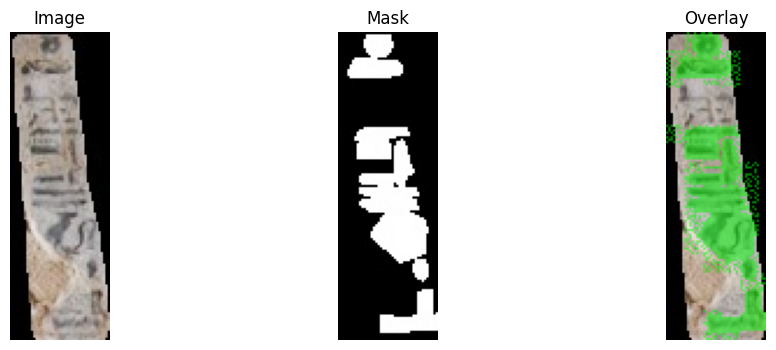

In [ ]:
# ============================================================
# 8) Visual check
# ============================================================
def show_pair(img_path, mask_path, figsize=(12, 4)):
    img_bgr = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img_bgr is None or mask is None:
        raise FileNotFoundError(f"Could not read image/mask:\n{img_path}\n{mask_path}")

    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    overlay = img.copy()
    overlay[mask > 0] = (0.5 * overlay[mask > 0] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)

    plt.figure(figsize=figsize)
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")
    plt.show()

if len(train_pairs) > 0:
    show_pair(*train_pairs[0])


In [ ]:
# ============================================================
# 8) Utility functions
# ============================================================
def mask_to_box(mask: np.ndarray, jitter: int = 0):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    if jitter > 0:
        x1 -= random.randint(0, jitter)
        y1 -= random.randint(0, jitter)
        x2 += random.randint(0, jitter)
        y2 += random.randint(0, jitter)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = max(x1 + 1, x2)
    y2 = max(y1 + 1, y2)
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)
    probs = probs.flatten(1)
    targets = targets.flatten(1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice.mean()

def compute_iou_and_dice(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)

    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)
    return iou.mean().item(), dice.mean().item()

In [ ]:
# ============================================================
# 9) Dataset class
# ============================================================
class HieroglyphSegDataset(Dataset):
    def __init__(self, pairs, sam_image_size=1024, bbox_jitter=0, min_mask_area=0):
        self.transform = ResizeLongestSide(sam_image_size)
        self.sam_image_size = sam_image_size
        self.bbox_jitter = bbox_jitter
        self.samples = []

        for img_path, mask_path in pairs:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue
            bin_mask = (mask > 0).astype(np.uint8)
            if bin_mask.sum() < min_mask_area:
                continue
            self.samples.append((img_path, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)

        original_size = image.shape[:2]  # (H, W)

        transformed_img = self.transform.apply_image(image)
        transformed_img_t = torch.as_tensor(transformed_img, dtype=torch.float32).permute(2, 0, 1)

        box = mask_to_box(mask, jitter=self.bbox_jitter)
        if box is None:
            raise ValueError(f"Empty mask for sample: {img_path}")

        transformed_box = self.transform.apply_boxes(box[None, :], original_size)[0]
        transformed_box_t = torch.tensor(transformed_box, dtype=torch.float32)

        mask_t = torch.tensor(mask[None, :, :], dtype=torch.float32)  # 1,H,W

        return {
            "image": transformed_img_t,
            "mask": mask_t,
            "box": transformed_box_t,
            "original_size": torch.tensor(original_size, dtype=torch.int64),
            "image_path": img_path,
        }


In [ ]:
# ============================================================
# 10) Dataloaders
# ============================================================
def collate_fn(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)
    masks = [b["mask"] for b in batch]
    boxes = torch.stack([b["box"] for b in batch], dim=0)
    original_sizes = torch.stack([b["original_size"] for b in batch], dim=0)
    image_paths = [b["image_path"] for b in batch]
    return {
        "images": images,
        "masks": masks,
        "boxes": boxes,
        "original_sizes": original_sizes,
        "image_paths": image_paths,
    }

train_ds = HieroglyphSegDataset(
    train_pairs,
    sam_image_size=cfg.sam_image_size,
    bbox_jitter=cfg.bbox_jitter,
    min_mask_area=cfg.min_mask_area,
)

val_ds = HieroglyphSegDataset(
    val_pairs,
    sam_image_size=cfg.sam_image_size,
    bbox_jitter=0,
    min_mask_area=cfg.min_mask_area,
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    collate_fn=collate_fn,
)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

Train samples: 271
Val samples: 28


In [ ]:
# ============================================================
# 11) Build SAM model
# ============================================================
sam = sam_model_registry[cfg.model_type](checkpoint=cfg.sam_checkpoint)
sam.to(device)
sam.train()

# freeze everything first
for p in sam.parameters():
    p.requires_grad = False

# always train mask decoder
for p in sam.mask_decoder.parameters():
    p.requires_grad = True

# optionally unfreeze image encoder blocks if desired
if not cfg.train_mask_decoder_only and cfg.unfreeze_last_n_image_encoder_blocks > 0:
    blocks = sam.image_encoder.blocks
    n = cfg.unfreeze_last_n_image_encoder_blocks
    for blk in blocks[-n:]:
        for p in blk.parameters():
            p.requires_grad = True

# count trainable params
trainable_params = sum(p.numel() for p in sam.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in sam.parameters())
print(f"Trainable params: {trainable_params:,} / {all_params:,}")

Trainable params: 4,058,340 / 93,735,472


In [ ]:
# ============================================================
# 12) Optimizer / AMP
# ============================================================
optimizer = torch.optim.AdamW(
    [p for p in sam.parameters() if p.requires_grad],
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
)

scaler = torch.cuda.amp.GradScaler(enabled=(cfg.mixed_precision and device == "cuda"))
bce_fn = nn.BCEWithLogitsLoss()

/tmp/ipykernel_11428/1437472213.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.mixed_precision and device == "cuda"))


In [ ]:
# ============================================================
# 13) Forward helper
# ============================================================
def forward_sam_batch(sam_model, images, boxes, original_sizes):
    """
    images: B,3,H',W' after ResizeLongestSide
    boxes: B,4 in transformed image coordinates
    original_sizes: B,2  -> (H, W) of original image
    returns logits resized to original image sizes (list of tensors)
    """
    images = images.to(device)
    boxes = boxes.to(device)

    # SAM preprocess (normalize + pad to square)
    processed_images = torch.stack([sam_model.preprocess(img) for img in images], dim=0)

    image_embeddings = sam_model.image_encoder(processed_images)

    outputs = []
    for i in range(images.shape[0]):
        box_i = boxes[i].unsqueeze(0)  # 1,4
        sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
            points=None,
            boxes=box_i,
            masks=None,
        )

        low_res_masks, iou_predictions = sam_model.mask_decoder(
            image_embeddings=image_embeddings[i].unsqueeze(0),
            image_pe=sam_model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        orig_size = tuple(original_sizes[i].tolist())
        upscaled_masks = sam_model.postprocess_masks(
            low_res_masks,
            input_size=images[i].shape[-2:],
            original_size=orig_size,
        )
        outputs.append(upscaled_masks)

    return outputs

In [ ]:
# ============================================================
# 14) Train / Val loops
# ============================================================
def train_one_epoch(model, loader, optimizer, scaler, epoch_idx):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    steps = 0

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f"Train {epoch_idx}", leave=False)

    for step, batch in enumerate(pbar):
        images = batch["images"]
        boxes = batch["boxes"]
        original_sizes = batch["original_sizes"]
        gt_masks = [m.to(device) for m in batch["masks"]]

        with torch.cuda.amp.autocast(enabled=(cfg.mixed_precision and device == "cuda")):
            pred_masks_list = forward_sam_batch(model, images, boxes, original_sizes)

            total_loss = 0.0
            batch_iou = 0.0
            batch_dice = 0.0

            for pred_mask, gt_mask in zip(pred_masks_list, gt_masks):
                gt_mask = gt_mask.unsqueeze(0) if gt_mask.dim() == 3 else gt_mask
                # pred_mask shape: [1,1,H,W]
                loss_bce = bce_fn(pred_mask, gt_mask)
                loss_dice = dice_loss(pred_mask, gt_mask)
                loss = cfg.bce_weight * loss_bce + cfg.dice_weight * loss_dice
                total_loss += loss

                iou, dice = compute_iou_and_dice(pred_mask, gt_mask, threshold=cfg.pred_threshold)
                batch_iou += iou
                batch_dice += dice

            total_loss = total_loss / len(pred_masks_list)
            batch_iou /= len(pred_masks_list)
            batch_dice /= len(pred_masks_list)

        scaler.scale(total_loss / cfg.grad_accum_steps).backward()

        if (step + 1) % cfg.grad_accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += total_loss.item()
        running_iou += batch_iou
        running_dice += batch_dice
        steps += 1

        pbar.set_postfix(loss=f"{running_loss/steps:.4f}", iou=f"{running_iou/steps:.4f}", dice=f"{running_dice/steps:.4f}")

    # flush last gradients if needed
    if steps % cfg.grad_accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    return {
        "loss": running_loss / max(steps, 1),
        "iou": running_iou / max(steps, 1),
        "dice": running_dice / max(steps, 1),
    }

@torch.no_grad()
def validate_one_epoch(model, loader, epoch_idx):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    steps = 0

    pbar = tqdm(loader, desc=f"Val {epoch_idx}", leave=False)
    for batch in pbar:
        images = batch["images"]
        boxes = batch["boxes"]
        original_sizes = batch["original_sizes"]
        gt_masks = [m.to(device) for m in batch["masks"]]

        pred_masks_list = forward_sam_batch(model, images, boxes, original_sizes)

        total_loss = 0.0
        batch_iou = 0.0
        batch_dice = 0.0

        for pred_mask, gt_mask in zip(pred_masks_list, gt_masks):
            gt_mask = gt_mask.unsqueeze(0) if gt_mask.dim() == 3 else gt_mask
            loss_bce = bce_fn(pred_mask, gt_mask)
            loss_dice = dice_loss(pred_mask, gt_mask)
            loss = cfg.bce_weight * loss_bce + cfg.dice_weight * loss_dice
            total_loss += loss

            iou, dice = compute_iou_and_dice(pred_mask, gt_mask, threshold=cfg.pred_threshold)
            batch_iou += iou
            batch_dice += dice

        total_loss = total_loss / len(pred_masks_list)
        batch_iou /= len(pred_masks_list)
        batch_dice /= len(pred_masks_list)

        running_loss += total_loss.item()
        running_iou += batch_iou
        running_dice += batch_dice
        steps += 1

        pbar.set_postfix(loss=f"{running_loss/steps:.4f}", iou=f"{running_iou/steps:.4f}", dice=f"{running_dice/steps:.4f}")

    return {
        "loss": running_loss / max(steps, 1),
        "iou": running_iou / max(steps, 1),
        "dice": running_dice / max(steps, 1),
    }

In [ ]:
# ============================================================
# 15) Training
# ============================================================
history = []
best_val_iou = -1.0
best_path = os.path.join(cfg.save_dir, "best_sam_hieroglyph.pth")
last_path = os.path.join(cfg.save_dir, "last_sam_hieroglyph.pth")

for epoch in range(1, cfg.epochs + 1):
    start = time.time()

    train_metrics = train_one_epoch(sam, train_loader, optimizer, scaler, epoch)
    val_metrics = validate_one_epoch(sam, val_loader, epoch)

    elapsed = time.time() - start
    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_iou": train_metrics["iou"],
        "train_dice": train_metrics["dice"],
        "val_loss": val_metrics["loss"],
        "val_iou": val_metrics["iou"],
        "val_dice": val_metrics["dice"],
        "time_sec": elapsed,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} train_iou={row['train_iou']:.4f} train_dice={row['train_dice']:.4f} | "
        f"val_loss={row['val_loss']:.4f} val_iou={row['val_iou']:.4f} val_dice={row['val_dice']:.4f} | "
        f"time={elapsed/60:.1f} min"
    )

    torch.save({
        "model_state_dict": sam.state_dict(),
        "cfg": cfg.__dict__,
        "history": history,
        "epoch": epoch,
    }, last_path)

    if row["val_iou"] > best_val_iou:
        best_val_iou = row["val_iou"]
        torch.save({
            "model_state_dict": sam.state_dict(),
            "cfg": cfg.__dict__,
            "history": history,
            "epoch": epoch,
        }, best_path)
        print(f"Saved best model to: {best_path}")

print("Best val IoU:", best_val_iou)

Train 1:   0%|          | 0/271 [00:00<?, ?it/s]

/tmp/ipykernel_11428/2750939555.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.mixed_precision and device == "cuda")):


Val 1:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7565 train_iou=0.6009 train_dice=0.7439 | val_loss=0.6236 val_iou=0.6581 val_dice=0.7882 | time=1.3 min
Saved best model to: /content/sam_hiero_finetune/best_sam_hieroglyph.pth


Train 2:   0%|          | 0/271 [00:00<?, ?it/s]

...

Val 13:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 13 | train_loss=0.4799 train_iou=0.7253 train_dice=0.8387 | val_loss=0.5663 val_iou=0.6866 val_dice=0.8109 | time=1.4 min


Train 14:   0%|          | 0/271 [00:00<?, ?it/s]

Val 14:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 14 | train_loss=0.4772 train_iou=0.7263 train_dice=0.8395 | val_loss=0.5364 val_iou=0.7053 val_dice=0.8242 | time=1.4 min


In [ ]:
# ============================================================
# 16) Plot learning curves
# ============================================================
if len(history) > 0:
    epochs = [h["epoch"] for h in history]

    plt.figure(figsize=(7,4))
    plt.plot(epochs, [h["train_loss"] for h in history], label="train_loss")
    plt.plot(epochs, [h["val_loss"] for h in history], label="val_loss")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, [h["train_iou"] for h in history], label="train_iou")
    plt.plot(epochs, [h["val_iou"] for h in history], label="val_iou")
    plt.legend()
    plt.title("IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, [h["train_dice"] for h in history], label="train_dice")
    plt.plot(epochs, [h["val_dice"] for h in history], label="val_dice")
    plt.legend()
    plt.title("Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.show()

In [ ]:
# ============================================================
# 17) Load best checkpoint
# ============================================================
ckpt = torch.load(best_path, map_location=device)
sam.load_state_dict(ckpt["model_state_dict"])
sam.eval()
print("Loaded best checkpoint from:", best_path)

In [ ]:
# ============================================================
# 18) Inference visualization on validation set
# ============================================================
@torch.no_grad()
def predict_single(model, sample):
    image_t = sample["image"].unsqueeze(0)
    box_t = sample["box"].unsqueeze(0)
    orig_size = sample["original_size"].unsqueeze(0)

    pred_masks = forward_sam_batch(model, image_t, box_t, orig_size)
    pred = torch.sigmoid(pred_masks[0])[0,0].cpu().numpy()
    return pred

def visualize_prediction(dataset, idx=0, threshold=0.5):
    sample = dataset[idx]
    img_path = sample["image_path"]
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    gt = sample["mask"][0].numpy()
    pred = predict_single(sam, sample)
    pred_bin = (pred > threshold).astype(np.uint8)

    overlay = image.copy()
    overlay[pred_bin > 0] = (0.5 * overlay[pred_bin > 0] + 0.5 * np.array([255,0,0])).astype(np.uint8)

    plt.figure(figsize=(14,4))
    plt.subplot(1,4,1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(gt, cmap="gray")
    plt.title("GT Mask")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(pred, cmap="gray")
    plt.title("Pred Prob")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(overlay)
    plt.title("Pred Overlay")
    plt.axis("off")
    plt.show()

if len(val_ds) > 0:
    visualize_prediction(val_ds, idx=min(3, len(val_ds)-1), threshold=cfg.pred_threshold)